Anamika Jagram Lodhi

Roll No : CE22

Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Step 2: Load the Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("auto-mpg.csv")

print("Dataset Loaded Successfully!")

Saving auto-mpg.csv to auto-mpg.csv
Dataset Loaded Successfully!


Step 3: Display Dataset Information

In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(398, 9)

Column Names:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


Step 4: Check Missing Values

In [ ]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


Step 5: Remove Missing Values

In [ ]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (398, 9)


Step 6: Select Horsepower and MPG

In [ ]:
X = pd.to_numeric(df['horsepower'], errors='coerce').values
Y = df['mpg'].values

# Drop rows where X became NaN after conversion
valid_indices = ~np.isnan(X)
X = X[valid_indices]
Y = Y[valid_indices]

print("Horsepower:")
print(X[:5])

print("\nMPG:")
print(Y[:5])

Horsepower:
[130. 165. 150. 150. 140.]

MPG:
[18. 15. 18. 16. 17.]


Step 7: Exploratory Data Analysis (EDA)

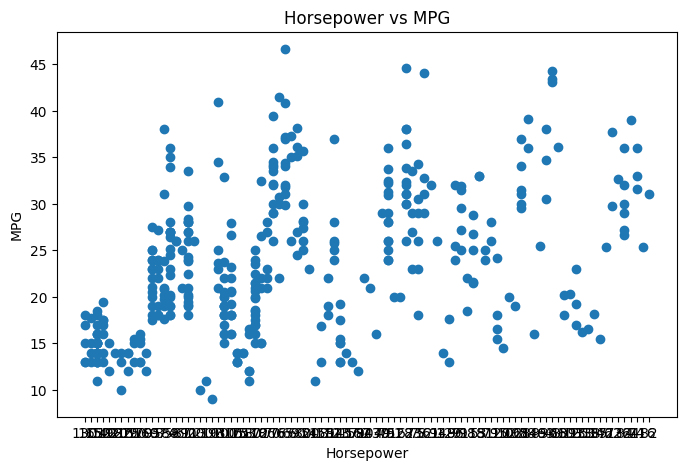

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X, Y)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

plt.show()

Step 8: Calculate Correlation

In [ ]:
numeric_horsepower = pd.to_numeric(df['horsepower'], errors='coerce')

correlation = numeric_horsepower.corr(df['mpg'])

print("Correlation =", correlation)

Correlation = -0.7784267838977756


Step 9: Add Bias (Intercept)

In [ ]:
X_bias = np.c_[np.ones(len(X)), X]

print(X_bias[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


Step 10: Calculate OLS Coefficients

In [ ]:
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept (w0):", weights[0])
print("Slope (w1):", weights[1])

Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387


Step 11: Predict MPG

In [ ]:
Y_pred = X_bias @ weights

print(Y_pred[:10])

[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Step 12: Calculate Residuals

In [ ]:
residuals = Y - Y_pred

print(residuals[:10])

[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Step 13: Calculate SSE

In [ ]:
SSE = np.sum(residuals ** 2)

print("SSE =", SSE)

SSE = 9385.915871932419


Step 14: Calculate MSE

In [ ]:
MSE = np.mean(residuals ** 2)

print("MSE =", MSE)

MSE = 23.943662938603108


Step 15: Calculate R² Score

In [ ]:
SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE/SST)

print("R² =", R2)

R² = 0.6059482578894348


Step 16: Plot Regression Line

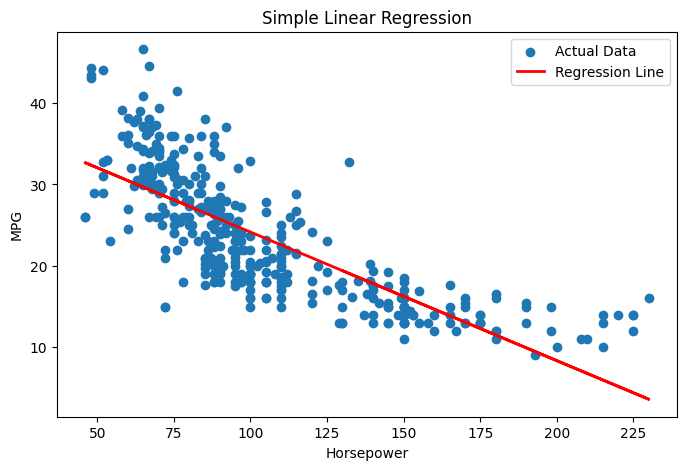

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X, Y, label="Actual Data")

plt.plot(X, Y_pred, color='red', linewidth=2, label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

Step 17: Plot Residual Graph

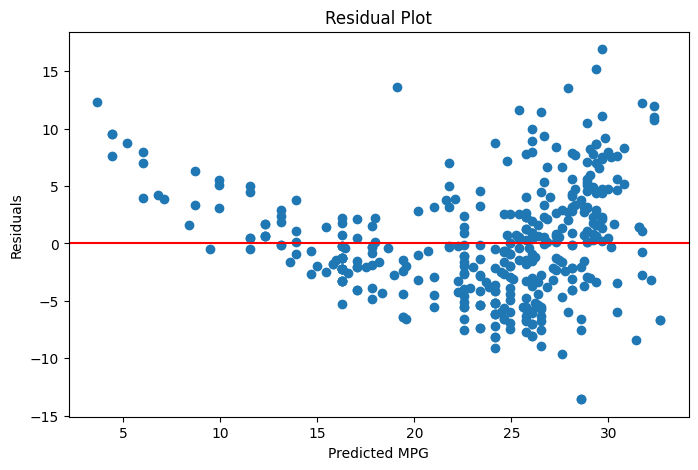

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(Y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()